# Βελτιστοποίηση Διαδρομών Παράδοσης Τελευταίου Χιλιομέτρου με το PROC OPTMODEL (Δίκτυο TSP)

## Συνοπτική Παρουσίαση

Μια περιφερειακή εταιρεία εφοδιαστικής πρέπει να δρομολογήσει ένα μοναδικό όχημα
παράδοσης μέσα από ένα σύνολο στάσεων πελατών και να επιστρέψει στην αποθήκη με
την ελάχιστη συνολική απόσταση διαδρομής — η δομή του προβλήματος του
πλανόδιου πωλητή (TSP) που διέπει τον καθημερινό σχεδιασμό διαδρομών και
βαρδιών. Αυτό το notebook συνθέτει συντεταγμένες στάσεων, κατασκευάζει έναν
συμμετρικό Ευκλείδειο πίνακα αποστάσεων, και χρησιμοποιεί τον επιλυτή δικτύου
`SOLVE WITH NETWORK / TSP` του **PROC OPTMODEL** για να κατασκευάσει μια
διαδρομή παράδοσης πάνω από το πλήρες γράφημα των στάσεων. Στη συνέχεια
διαβάζει τη σειρά διαδρομής του επιλυτή πίσω σε ένα βήμα DATA, ανασυνθέτει μια
κλειστή διαδρομή αγκυρωμένη στην αποθήκη, και μετρά το **πραγματικό** συνολικό
μήκος της από τον πίνακα αποστάσεων. Κάθε αριθμός που αναφέρεται παρακάτω
υπολογίζεται από την εκτελεσμένη έξοδο.

## Πηγές Δεδομένων

Όλα τα δεδομένα παράγονται ενσωματωμένα με `call streaminit(...)` και
`rand(...)` — χωρίς εξωτερικά αρχεία ή πρόσβαση δικτύου.

| Σύνολο Δεδομένων | Γραμμές | Βασικές μεταβλητές | Περιγραφή |
|---------|------|---------------|-------------|
| `stops` | 12 (1 αποθήκη + 11 πελάτες) | `stop_id`, `name`, `x`, `y` | Συνθετικές 2-Δ συντεταγμένες (χλμ σε πλέγμα περιοχής εξυπηρέτησης) για την αποθήκη και τις τοποθεσίες παράδοσης πελατών |
| `tour` | 12 | `visit_order`, `node` | Η διατεταγμένη λίστα στάσεων που επισκέπτεται ο επιλυτής δικτύου TSP του OPTMODEL, γραμμένη από το `OUT=(TOUR=...)` |
| `route` | 12 | `visit_order`, `node`, `step_name`, `x`, `y`, `leg_km`, `cum_km` | Η κλειστή διαδρομή αγκυρωμένη στην αποθήκη με αποστάσεις ανά σκέλος και αθροιστικές, υπολογισμένες από τις συντεταγμένες |

Μια εταιρεία παράδοσης τελευταίου χιλιομέτρου αποστέλλει ένα φορτηγάκι κάθε πρωί
για να παραδώσει σε ένα σταθερό σύνολο στάσεων πελατών και να επιστρέψει στην
αποθήκη. Ο διαχειριστής αποστολών θέλει μια σύντομη κλειστή διαδρομή που
επισκέπτεται κάθε στάση ακριβώς μία φορά — το πρόβλημα του πλανόδιου πωλητή
(TSP) στον πυρήνα του καθημερινού προγραμματισμού διαδρομών και βαρδιών.

Το SAS/OR εκθέτει έναν επιλυτή TSP μέσω του **`PROC OPTMODEL`**: δηλώστε τους
κόμβους και ένα σταθμισμένο σύνολο ακμών, μετά `SOLVE WITH NETWORK / TSP`.
Αυτό το notebook:

1. Συνθέτει συντεταγμένες στάσεων και έναν συμμετρικό πίνακα αποστάσεων.
2. Καλεί τον επιλυτή δικτύου TSP του OPTMODEL πάνω στο πλήρες γράφημα των στάσεων.
3. Διαβάζει τη διαδρομή του επιλυτή πίσω και ανασυνθέτει μια κλειστή διαδρομή
   αγκυρωμένη στην αποθήκη.
4. Αναφέρει τη διαδρομή και το μετρημένο συνολικό μήκος της, σκέλος προς σκέλος.

## Βήμα 1 — Δημιουργία του δικτύου παράδοσης

Τοποθετούμε μια αποθήκη στο κέντρο μιας περιοχής εξυπηρέτησης 100 χλμ x 100 χλμ
και διασκορπίζουμε 11 στάσεις πελατών ομοιόμορφα στο πλέγμα. Οι συντεταγμένες
αντλούνται με `rand('UNIFORM')` υπό ένα σταθερό σπόρο `streaminit` ώστε το
δίκτυο να είναι αναπαραγώγιμο. Η αποθήκη έχει `stop_id = 1`· η διαδρομή θα
ξεκινά και θα τελειώνει εκεί.

In [1]:
ΔΕΔΟΜΕΝΑ stops;
    CALL streaminit(20260531);
    LENGTH name $20;
    n_stops = 12;                 /* 1 αποθήκη + 11 πελάτες */
    ΕΠΑΝΑΛΗΨΗ stop_id = 1 ΕΩΣ n_stops;
        ΕΑΝ stop_id = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            name = "Αποθήκη";
            x = 50; y = 50;       /* η αποθήκη είναι αγκυρωμένη στο κέντρο του πλέγματος */
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            name = cats('Στάση_', PUT(stop_id - 1, z2.));
            x = round(rand('UNIFORM') * 100, 0.1);
            y = round(rand('UNIFORM') * 100, 0.1);
        ΤΕΛΟΣ;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ n_stops;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=stops noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ stop_id = 'Στάση #' name = 'Τοποθεσία' x = 'X (χλμ)' y = 'Y (χλμ)';
    TITLE 'Δίκτυο Παράδοσης: Αποθήκη και Στάσεις Πελατών';
ΕΚΤΕΛΕΣΗ;

                                     Δίκτυο Παράδοσης: Αποθήκη και Στάσεις Πελατών                                      

         Τοποθεσία       Στάση #     X (χλμ)     Y (χλμ)
Αποθήκη                        1          50          50
Στάση_01                       2        84.2        89.7
Στάση_02                       3        93.1        73.6
Στάση_03                       4        21.2          29
Στάση_04                       5        49.4        73.4
Στάση_05                       6        97.8        37.2
Στάση_06                       7          28        51.3
Στάση_07                       8        91.1        86.5
Στάση_08                       9        89.2        65.6
Στάση_09                      10          66        49.4
Στάση_10                      11        52.2        27.4
Στάση_11                      12        62.4        38.2




NOTE: DATA stops


NOTE: Wrote stops (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=stops

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


## Βήμα 2 — Επίλυση του TSP με το PROC OPTMODEL

Διαβάζουμε τις συντεταγμένες στο OPTMODEL, δηλώνουμε το πλήρες μη
κατευθυνόμενο σύνολο ακμών `EDGES` (κάθε μη διατεταγμένο ζεύγος στάσεων), και
ορίζουμε το βάρος κάθε ακμής ως την Ευκλείδεια απόσταση μεταξύ των άκρων της.
Το `SOLVE WITH NETWORK / TSP` κατασκευάζει τότε μια διαδρομή πάνω σε αυτό το
γράφημα και γράφει τη σειρά επίσκεψης σε ένα CSV μέσω του `OUT=(TOUR=...)`.
Διαβάζουμε αμέσως αυτή τη σειρά πίσω στο σύνολο δεδομένων `tour`.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ optmodel;
    ΟΡΙΣΜΟΣ CITIES = 1..12;
    num XC{CITIES};
    num YC{CITIES};

    /* Άντληση των συντεταγμένων των στάσεων από το βήμα DATA */
    READ ΔΕΔΟΜΕΝΑ stops INTO [stop_id] XC=x YC=y;

    /* Πλήρες γράφημα: μία μη κατευθυνόμενη ακμή ανά μη διατεταγμένο ζεύγος στάσεων */
    ΟΡΙΣΜΟΣ EDGES = {i IN CITIES, j IN CITIES: i < j};

    /* Βάρος ακμής = ευθύγραμμη (Ευκλείδεια) απόσταση, σε χλμ */
    num DIST{<i,j> IN EDGES} =
        sqrt( (XC[i]-XC[j])^2 + (YC[i]-YC[j])^2 );

    /* Επιλυτής δικτύου TSP: επίσκεψη κάθε κόμβου και επιστροφή στην αρχή */
    solve WITH network /
        links = (include=EDGES ΒΑΡΟΣ=DIST)
        tsp
        out   = (tour="tour.csv");
QUIT;

/* Ανάγνωση της σειράς επίσκεψης του επιλυτή πίσω */
ΔΕΔΟΜΕΝΑ tour;
    INFILE "tour.csv" dlm=',' firstobs=2 dsd;
    ΕΙΣΟΔΟΣ visit_order node;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=tour noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ visit_order = 'Επίσκεψη #' node = 'Στάση #';
    TITLE 'Σειρά Διαδρομής που Επέστρεψε ο Επιλυτής Δικτύου TSP του OPTMODEL';
ΕΚΤΕΛΕΣΗ;

                                     Δίκτυο Παράδοσης: Αποθήκη και Στάσεις Πελατών                                      


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            dist
  Objective Type                Linear

  Number of Nodes               12
  Number of Links               66

                          Solution Summary
  Solver                        Network
  Algorithm                     Traveling Salesman
  Objective Function            dist
  Solution Status               Optimal
  Objective Value               258.1425005024

                           Σειρά Διαδρομής που Επέστρεψε ο Επιλυτής Δικτύου TSP του OPTMODEL                            

        Επίσκεψη #       Στάση #
                 1             1
                 2             7
                 3             4
                 4            11
                 5            12
              


NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.
NOTE: DATA tour

NOTE: Reading from fileref tour.csv (tour.csv)

NOTE: Read 12 rows from tour.csv.
NOTE: Wrote tour (12 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=tour

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Βήμα 3 — Ανασύνθεση της κλειστής διαδρομής και μέτρηση του μήκους της

Ο επιλυτής επιστρέφει μόνο τη *σειρά* με την οποία πρέπει να επισκεφθούμε τις
στάσεις. Για να το μετατρέψουμε σε δελτίο οδηγού αναζητούμε το όνομα και τις
συντεταγμένες κάθε στάσης με μια αναζήτηση `SET ... POINT=`, συσσωρεύουμε την
απόσταση κάθε σκέλους, και κλείνουμε τον βρόχο προσθέτοντας το τελευταίο
σκέλος πίσω στην αποθήκη. Το `leg_km` είναι το μήκος του σκέλους που
*καταλήγει* σε κάθε στάση· το `cum_km` είναι η τρέχουσα απόσταση από την
αποθήκη.

In [3]:
ΔΕΔΟΜΕΝΑ route;
    ΟΡΙΣΜΟΣ tour ΤΕΛΟΣ=last;
    /* Αναζήτηση των συντεταγμένων και του ονόματος αυτής της στάσης βάσει του id της */
    ptr = node;
    ΟΡΙΣΜΟΣ stops point=ptr;

    LENGTH step_name $20;
    step_name = name;

    RETAIN prevx prevy firstx firsty cum_km;
    ΕΑΝ _n_ = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        firstx = x; firsty = y;      /* απομνημόνευση της αποθήκης */
        leg_km = 0;                  /* κανένα σκέλος δεν καταλήγει στην αρχή */
        cum_km = 0;
    ΤΕΛΟΣ;
    ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
        leg_km = sqrt( (x-prevx)**2 + (y-prevy)**2 );
        cum_km + leg_km;
    ΤΕΛΟΣ;
    prevx = x; prevy = y;
    ΕΞΟΔΟΣ;

    ΕΑΝ last ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        /* Σκέλος κλεισίματος: από την τελευταία στάση πίσω στην αποθήκη */
        leg_km = sqrt( (firstx-prevx)**2 + (firsty-prevy)**2 );
        cum_km + leg_km;
        node = 1; visit_order = 13; step_name = "Αποθήκη";
        x = firstx; y = firsty;
        ΕΞΟΔΟΣ;
        CALL symputx('total_km', PUT(cum_km, 8.2));
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ visit_order node step_name x y leg_km cum_km;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=route noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ visit_order = 'Βήμα' node = 'Στάση #' step_name = 'Τοποθεσία'
          x = 'X (χλμ)' y = 'Y (χλμ)'
          leg_km = 'Σκέλος (χλμ)' cum_km = 'Αθροιστικά (χλμ)';
    ΜΟΡΦΗ leg_km cum_km 7.2;
    TITLE "Κλειστή Διαδρομή Παράδοσης (Σύνολο: &total_km χλμ)";
ΕΚΤΕΛΕΣΗ;

                                    Κλειστή Διαδρομή Παράδοσης (Σύνολο: 258.14 χλμ)                                     

    Βήμα       Στάση #           Τοποθεσία     X (χλμ)     Y (χλμ)           Σκέλος (χλμ)               Αθροιστικά (χλμ)
       1             1  Αποθήκη                     50          50                   0.00                           0.00
       2             7  Στάση_06                    28        51.3                  22.04                          22.04
       3             4  Στάση_03                  21.2          29                  23.31                          45.35
       4            11  Στάση_10                  52.2        27.4                  31.04                          76.39
       5            12  Στάση_11                  62.4        38.2                  14.86                          91.25
       6            10  Στάση_09                    66        49.4                  11.76                         103.01
       7             6  Στάση_0


NOTE: DATA route


NOTE: Read 12 rows from tour.
NOTE: Wrote route (13 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=route

NOTE: PROC PRINT completed: 13 observations printed, 7 variables


## Βήμα 4 — Ένα ευανάγνωστο δελτίο οδηγού

Τέλος συμπτύσσουμε τη διαδρομή σε μία μοναδική ευανάγνωστη συμβολοσειρά — τη
σειρά ονομάτων στάσεων από την αποθήκη, γύρω από τους πελάτες, και πίσω — συν
την μετρημένη συνολική απόσταση που θα διανύσει το φορτηγάκι.

In [4]:
ΔΕΔΟΜΕΝΑ manifest;
    ΟΡΙΣΜΟΣ route ΤΕΛΟΣ=last;
    LENGTH route_text $300;
    RETAIN route_text '';
    ΕΑΝ _n_ = 1 ΤΟΤΕ route_text = strip(step_name);
    ΑΛΛΙΩΣ route_text = catx(' -> ', route_text, strip(step_name));
    ΕΑΝ last ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        total_km = cum_km;
        ΚΡΑΤΗΣΗ route_text total_km;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=manifest noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ route_text = 'Βελτιστοποιημένη Διαδρομή Παράδοσης'
          total_km   = 'Συνολική Απόσταση (χλμ)';
    ΜΟΡΦΗ total_km 7.2;
    TITLE 'Δελτίο Οδηγού';
ΕΚΤΕΛΕΣΗ;

                                                     Δελτίο Οδηγού                                                      

                                                                                                                                                                                        Βελτιστοποιημένη Διαδρομή Παράδοσης                     Συνολική Απόσταση (χλμ)
Αποθήκη -> Στάση_06 -> Στάση_03 -> Στάση_10 -> Στάση_11 -> Στάση_09 -> Στάση_05 -> Στάση_08 -> Στάση_02 -> Στάση_07 -> Στάση_01 -> Στάση_04 -> Αποθήκη                                                                                                           258.14




NOTE: DATA manifest


NOTE: Read 13 rows from route.
NOTE: Wrote manifest (1 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=manifest

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## Βήμα 5 — Σχεδίαση της διαδρομής

Μια εικόνα επιβεβαιώνει ότι η διαδρομή είναι λογική: στάσεις συνδεδεμένες με
τη σειρά επίσκεψης, η αποθήκη σημειωμένη, χωρίς προφανώς σπάταλες διασταυρώσεις.
Σχεδιάζουμε την κλειστή διαδρομή ως μια σειρά συνδεδεμένων ευθύγραμμων τμημάτων
πάνω στο πλέγμα της περιοχής εξυπηρέτησης.

                                                     Δελτίο Οδηγού                                                      




NOTE: PROC SGPLOT data=route

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


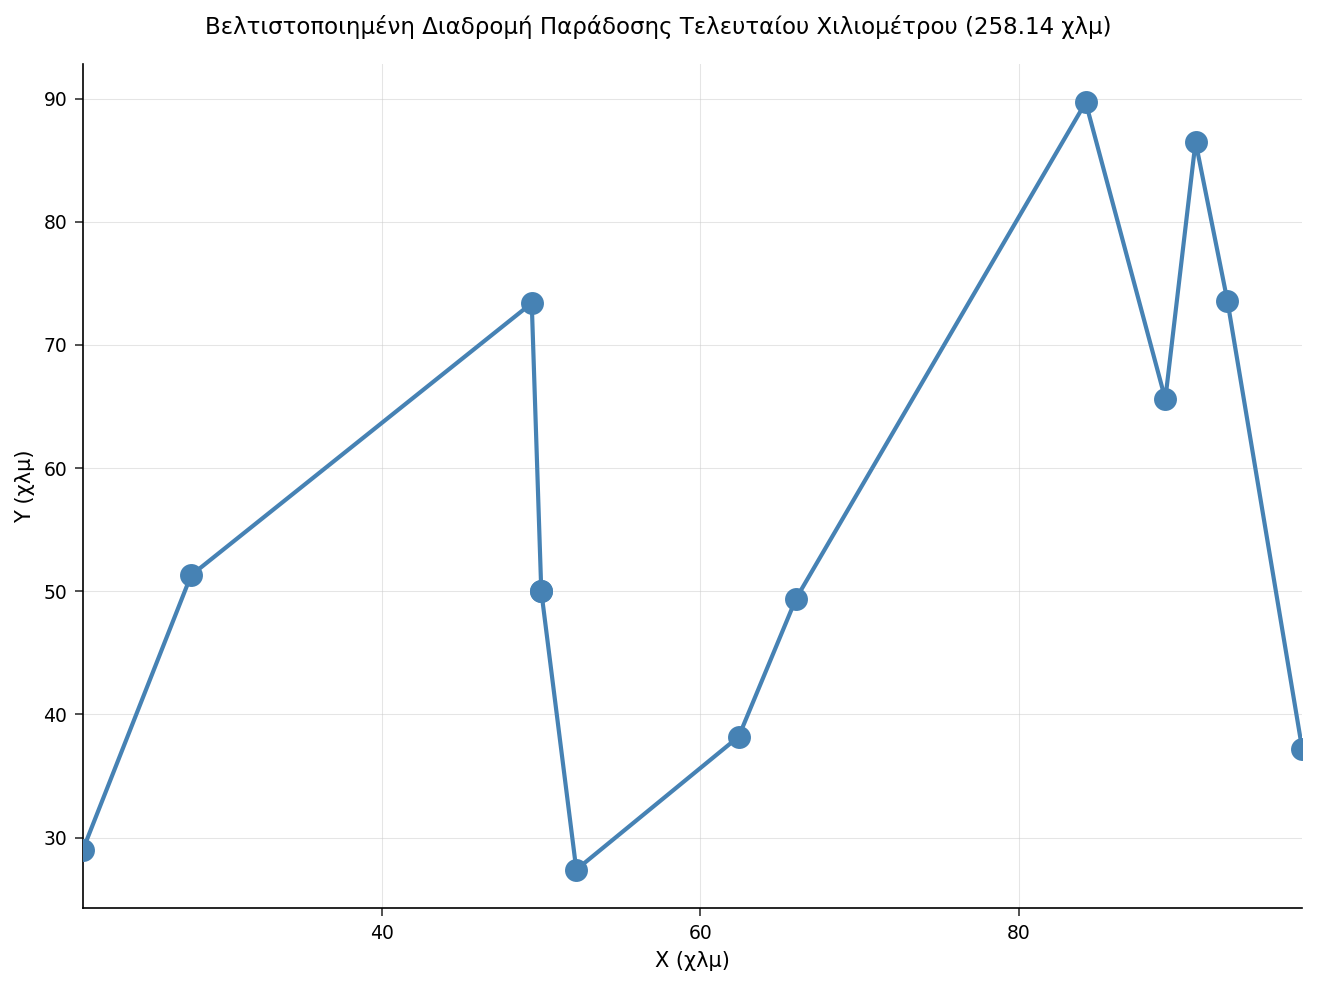

In [5]:
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=route noautolegend;
    SERIES x=x y=y / LINEATTRS=(color=steelblue thickness=2);
    SCATTER x=x y=y / MARKERATTRS=(SYMBOL=circlefilled
                      color=steelblue size=10);
    XAXIS ΕΤΙΚΕΤΑ='X (χλμ)' grid;
    YAXIS ΕΤΙΚΕΤΑ='Y (χλμ)' grid;
    TITLE "Βελτιστοποιημένη Διαδρομή Παράδοσης Τελευταίου Χιλιομέτρου (&total_km χλμ)";
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

- **Η διαδρομή.** Οι πίνακες `route` και `manifest` δίνουν την κλειστή διαδρομή
  που παρήγαγε ο επιλυτής δικτύου TSP του OPTMODEL πάνω στο πλήρες γράφημα των
  12 στάσεων, ξεκινώντας και τελειώνοντας στην αποθήκη. Η `Συνολική Απόσταση`
  είναι *μετρημένη*: είναι το άθροισμα των Ευκλείδειων αποστάσεων ανά σκέλος
  (`leg_km`), οπότε αντικατοπτρίζει την πραγματική γεωμετρία του δικτύου αντί
  για έναν υποτιθέμενο αριθμό.
- **Γιατί ένας επιλυτής δικτύου εδώ.** Με 11 στάσεις πελατών υπάρχουν
  `11! / 2 = 19,958,400` διακριτές κλειστές διαδρομές, οπότε ο διαχειριστής
  αποστολών χρειάζεται έναν αλγόριθμο αντί για απαρίθμηση. Το
  `SOLVE WITH NETWORK / TSP` κατασκευάζει μια διαδρομή απευθείας από το
  σταθμισμένο σύνολο ακμών χωρίς ο αναλυτής να κωδικοποιεί χειροκίνητα την
  αναζήτηση.
- **Από τη σειρά στο δελτίο.** Ο επιλυτής επιστρέφει μια *σειρά* επίσκεψης· το
  βήμα DATA τη μετατρέπει σε ένα λειτουργικό τεχνούργημα — ονομασμένες στάσεις,
  αποστάσεις ανά σκέλος, ένα τρέχον χιλιομετρητή, και ένα μονόγραμμο δελτίο
  που μπορεί να ακολουθήσει ένας οδηγός.
- **Λειτουργικές επεκτάσεις.** Το ίδιο σκελετό OPTMODEL κλιμακώνεται σε
  πλουσιότερη δρομολόγηση: προσθέστε περιορισμούς χωρητικότητας ή χρονικού
  παραθύρου ως πρόσθετες επιλογές δικτύου, σταθμίστε τις ακμές με χρόνο οδήγησης
  αντί για ευθύγραμμη απόσταση, ή κατανείμετε τις στάσεις σε πολλαπλά οχήματα
  πριν επιλύσετε ένα TSP ανά όχημα.